In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

raw_data = pd.read_csv("Bus_Breakdown_and_Delays_20260713.csv")
raw_data

/tmp/ipykernel_79153/3564257624.py:5: DtypeWarning: Columns (0: Reason, 1: Incident_Number) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv("Bus_Breakdown_and_Delays_20260713.csv")


,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
0,2015-2016,1272996,Special Ed AM Run,2256,K355,Won`t Start,15879,06/03/2016 06:03:00 AM,06/03/2016 06:05:00 AM,Brooklyn,...,NaN,0,Yes,Yes,Yes,06/03/2016 06:05:00 AM,NaN,06/03/2016 06:05:05 AM,Breakdown,School-Age
1,2016-2017,1313907,Special Ed AM Run,4481,K002,Won`t Start,22001,01/10/2017 05:55:00 AM,01/10/2017 05:57:00 AM,Brooklyn,...,30min,0,Yes,Yes,No,01/10/2017 05:57:00 AM,NaN,01/10/2017 05:57:42 AM,Running Late,School-Age
2,2015-2016,1267391,Special Ed AM Run,GT2114,Y925,Won`t Start,11012,05/11/2016 05:50:00 AM,05/11/2016 05:59:00 AM,Bronx,...,30 MIN,0,Yes,Yes,Yes,05/11/2016 05:59:00 AM,NaN,05/11/2016 05:59:42 AM,Running Late,School-Age
3,2016-2017,1312240,General Ed AM Run,2436,K1546,Other,15032,01/05/2017 06:00:00 AM,01/05/2017 06:05:00 AM,Brooklyn,...,20 MINS,0,No,No,No,01/05/2017 06:05:00 AM,NaN,01/05/2017 06:05:48 AM,Running Late,School-Age
4,2016-2017,1312351,Special Ed AM Run,5814D,X441,Mechanical Problem,11002,01/05/2017 06:45:00 AM,01/05/2017 06:54:00 AM,Bronx,...,NaN,0,Yes,Yes,No,01/05/2017 06:54:00 AM,NaN,01/05/2017 10:50:02 AM,Breakdown,School-Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294124,2025-2026,2017459,Pre-K/EI,GV9345,RDN#3,Heavy Traffic,C601,09/26/2025 08:30:00 AM,09/26/2025 08:33:00 AM,Bronx,...,16-30 Min,17,Yes,Yes,No,09/26/2025 08:33:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,Pre-K
1294125,2025-2026,2018252,Special Ed AM Run,97,K905,Heavy Traffic,"21736,21741",09/30/2025 07:14:00 AM,09/30/2025 07:17:00 AM,Brooklyn,...,16-30 Min,1,No,No,No,09/30/2025 07:17:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
1294126,2025-2026,2018472,General Ed PM Run,670,X9233,Other,11454,09/30/2025 02:32:00 PM,09/30/2025 02:33:00 PM,Bronx,...,16-30 Min,10,No,No,No,09/30/2025 02:33:00 PM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
1294127,2025-2026,2017966,Special Ed AM Run,23028,P851,Heavy Traffic,"25024,25802",09/29/2025 08:00:00 AM,09/29/2025 08:29:00 AM,Queens,...,61-90 Min,7,Yes,No,No,09/29/2025 08:29:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age


# Bus Breakdown and Delays has NaN values in Reason column

In [2]:
raw_data['Reason'].unique()

<StringArray>
[                'Won`t Start',                       'Other',
          'Mechanical Problem',                   'Flat Tire',
                    'Accident',               'Heavy Traffic',
                 'Problem Run',          'Weather Conditions',
 'Late return from Field Trip',           'Delayed by School',
                           nan]
Length: 11, dtype: str

In [3]:
missing_reason = raw_data[raw_data['Reason'].isna()]
missing_reason

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
956,NaN,780868,Special Ed AM Run,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,No,No,No,NaN,NaN,NaN,Breakdown,School-Age
4345,2001-2002,786171,Special Ed PM Run,9033,K802,NaN,22286,02/06/2002 02:30:00 PM,02/06/2002 02:35:00 PM,Brooklyn,...,NaN,0,Yes,Yes,Yes,02/06/2002 02:35:00 PM,NaN,02/06/2002 05:12:17 PM,Breakdown,School-Age
5451,2001-2002,787799,Special Ed PM Run,3,K566,NaN,17862,06/07/2002 02:35:00 PM,06/07/2002 02:55:00 PM,Brooklyn,...,15 MIN.,12,Yes,Yes,Yes,06/07/2002 02:55:00 PM,NaN,06/07/2002 04:02:54 PM,Running Late,School-Age
5555,2001-2002,787963,Special Ed AM Run,309,K449,NaN,"19302,19906",06/21/2002 07:18:00 AM,06/21/2002 07:25:00 AM,Brooklyn,...,NaN,4,Yes,Yes,Yes,06/21/2002 07:25:00 AM,NaN,06/21/2002 11:04:30 AM,Breakdown,School-Age
5995,2002-2003,788579,Special Ed AM Run,185,K882,NaN,20205,09/20/2002 08:30:00 AM,09/20/2002 08:46:00 AM,Brooklyn,...,NaN,3,Yes,Yes,Yes,09/20/2002 08:46:00 AM,NaN,09/20/2002 12:09:07 PM,Breakdown,School-Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932726,2019-2020,818510,Special Ed AM Run,015103,K090,NaN,18219,06/01/2020 07:17:00 AM,06/01/2006 07:26:00 AM,Brooklyn,...,20mins,0,No,No,No,06/01/2006 07:26:00 AM,NaN,06/01/2006 07:29:44 AM,Running Late,School-Age
932727,2019-2020,826219,Special Ed AM Run,741,K261,NaN,14319,01/30/2020 04:05:00 PM,01/30/2007 04:11:00 PM,Brooklyn,...,NaN,15,Yes,No,Yes,01/30/2007 04:11:00 PM,NaN,01/30/2007 04:13:03 PM,Breakdown,School-Age
932728,2019-2020,876179,Special Ed AM Run,187,K035,NaN,16455,01/29/2020 07:52:00 AM,01/28/2009 07:52:00 AM,Brooklyn,...,30MIN,12,Yes,Yes,Yes,01/28/2009 07:52:00 AM,NaN,01/28/2009 07:54:21 AM,Running Late,School-Age
932729,2019-2020,918982,Special Ed AM Run,555,W642,NaN,75876,04/28/2020 07:00:00 AM,04/28/2010 11:27:00 AM,Westchester,...,40min,3,Yes,Yes,Yes,04/28/2010 11:27:00 AM,NaN,04/28/2010 11:28:15 AM,Running Late,School-Age


# We see that there are around 140,000 rows with Reason as Nan so we can clean it up

In [4]:
raw_data['Reason'] = raw_data['Reason'].fillna("Unknown")
raw_data.sample(20)

,School_Year,Busbreakdown_ID,Run_Type,Bus_No,Route_Number,Reason,Schools_Serviced,Occurred_On,Created_On,Boro,...,How_Long_Delayed,Number_Of_Students_On_The_Bus,Has_Contractor_Notified_Schools,Has_Contractor_Notified_Parents,Have_You_Alerted_OPT,Informed_On,Incident_Number,Last_Updated_On,Breakdown_or_Running_Late,School_Age_or_PreK
937582,2020-2021,1642834,Special Ed PM Run,16407,X245,Mechanical Problem,"09327,09455,09555",01/29/2021 01:55:00 PM,01/29/2021 02:03:00 PM,Bronx,...,31-45 Min,0,Yes,Yes,No,01/29/2021 02:03:00 PM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
1114258,2022-2023,1821618,General Ed AM Run,601,R9083,Heavy Traffic,"31057,31090",05/10/2023 02:38:00 AM,05/10/2023 02:39:00 PM,Staten Island,...,31-45 Min,0,No,No,No,05/10/2023 02:39:00 PM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
1127914,2023-2024,1835316,Special Ed AM Run,VS0090,L600,Other,"32025,32376,32377",07/24/2023 06:30:00 AM,07/24/2023 07:44:00 AM,Brooklyn,...,31-45 Min,0,Yes,Yes,No,07/24/2023 07:44:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
494191,2014-2015,1194211,Pre-K/EI,9320,2,Other,C375,04/15/2015 06:59:00 AM,04/15/2015 07:00:00 AM,Bronx,...,30 MINS,0,Yes,Yes,No,04/15/2015 07:00:00 AM,NaN,04/15/2015 07:01:17 AM,Running Late,Pre-K
942419,2020-2021,1647663,Special Ed AM Run,1638,N442,Heavy Traffic,"02111,02744",04/06/2021 08:20:00 AM,04/06/2021 08:20:00 AM,Manhattan,...,46-60 Min,0,Yes,Yes,No,04/06/2021 08:20:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
813789,2018-2019,1517997,Pre-K/EI,9355,10,Heavy Traffic,C579,02/08/2019 08:46:00 AM,02/08/2019 08:48:00 AM,Bronx,...,46-60 Min,2,Yes,Yes,No,02/08/2019 08:48:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,Pre-K
877502,2019-2020,1581731,General Ed AM Run,27829,K2194,Mechanical Problem,"21215,22234",10/02/2019 06:45:00 AM,10/02/2019 07:00:00 AM,Brooklyn,...,16-30 Min,0,Yes,No,No,10/02/2019 07:00:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
777795,2018-2019,1481963,General Ed AM Run,22976,M1040,Heavy Traffic,"02031,02059",11/07/2018 07:39:00 AM,11/07/2018 07:40:00 AM,Manhattan,...,31-45 Min,5,Yes,No,No,11/07/2018 07:40:00 AM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age
228850,2010-2011,924774,Special Ed AM Run,16197,M658,Unknown,04096,07/01/2010 07:00:00 AM,07/01/2010 07:50:00 AM,Manhattan,...,30 mins,4,Yes,Yes,Yes,07/01/2010 07:50:00 AM,NaN,07/01/2010 07:52:18 AM,Running Late,School-Age
1183475,2023-2024,1898757,Special Ed PM Run,96,N121,Problem Run,"03480,03931",02/09/2024 02:11:00 PM,02/09/2024 02:12:00 PM,Manhattan,...,16-30 Min,0,Yes,Yes,No,02/09/2024 02:12:00 PM,NaN,01/01/1900 12:00:00 AM,Running Late,School-Age


In [5]:
raw_data['Boro'].value_counts()

Boro
Brooklyn           315554
Bronx              294288
Manhattan          256370
Queens             248396
Staten Island       62027
Nassau County       43585
Westchester         33085
New Jersey           6139
Connecticut          4445
All Boroughs         3397
Rockland County      2543
Suffolk               221
Name: count, dtype: int64

# Brooklyn has the highest and second highest is the bronx, however we need more information on the type of reason

In [6]:
raw_data["Reason"].unique()

<StringArray>
[                'Won`t Start',                       'Other',
          'Mechanical Problem',                   'Flat Tire',
                    'Accident',               'Heavy Traffic',
                 'Problem Run',          'Weather Conditions',
 'Late return from Field Trip',           'Delayed by School',
                     'Unknown']
Length: 11, dtype: str

In [7]:
raw_data["Reason"].value_counts()

Reason
Heavy Traffic                  680510
Other                          192512
Unknown                        144304
Mechanical Problem              99664
Problem Run                     42328
Won`t Start                     37999
Weather Conditions              35599
Flat Tire                       22617
Late return from Field Trip     17367
Delayed by School               11312
Accident                         9917
Name: count, dtype: int64

In [8]:
aggregated_reason = raw_data[['Boro', 'Reason']]
aggregated_reason.sample(20)

,Boro,Reason
361724,Bronx,Heavy Traffic
594750,Staten Island,Heavy Traffic
93298,Queens,Unknown
1261199,Bronx,Mechanical Problem
573745,Brooklyn,Heavy Traffic
1022044,Brooklyn,Other
740161,Bronx,Other
1158709,Manhattan,Problem Run
979545,Queens,Heavy Traffic
1258877,Bronx,Weather Conditions


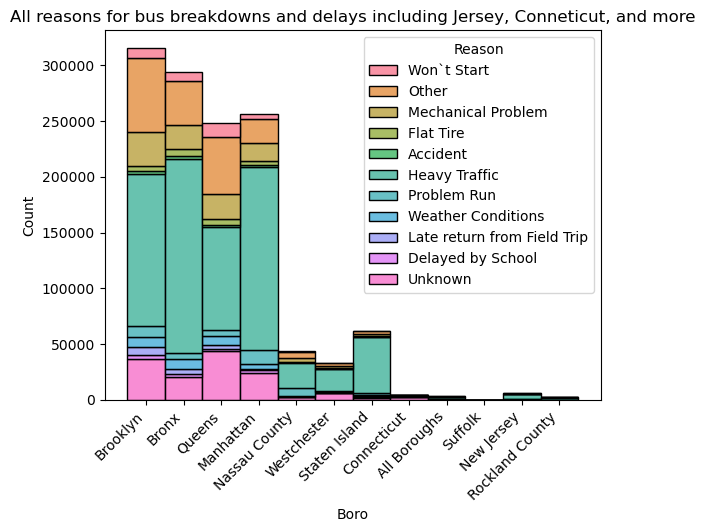

In [9]:
sns.histplot(
    aggregated_reason,
    x = 'Boro',
    hue = 'Reason',
    multiple = 'stack'
)
plt.title("All reasons for bus breakdowns and delays including Jersey, Conneticut, and more")
plt.xticks(rotation=45, ha="right") 
plt.show()

# We can be more specific with the 5 boroughs

In [10]:
five_Boro = ['Bronx', 'Queens', 'Brooklyn', 'Manhattan', 'Staten Island']
aggregated_reason['Filtered_Borough'] = aggregated_reason['Boro'].where(aggregated_reason['Boro'].isin(five_Boro))
aggregated_reason.sample(20)

,Boro,Reason,Filtered_Borough
269047,Brooklyn,Mechanical Problem,Brooklyn
22562,Brooklyn,Heavy Traffic,Brooklyn
140339,Queens,Unknown,Queens
453369,Manhattan,Heavy Traffic,Manhattan
496367,Brooklyn,Late return from Field Trip,Brooklyn
477764,Brooklyn,Weather Conditions,Brooklyn
1111274,Staten Island,Weather Conditions,Staten Island
1204054,Bronx,Heavy Traffic,Bronx
864134,Brooklyn,Heavy Traffic,Brooklyn
465466,Bronx,Weather Conditions,Bronx


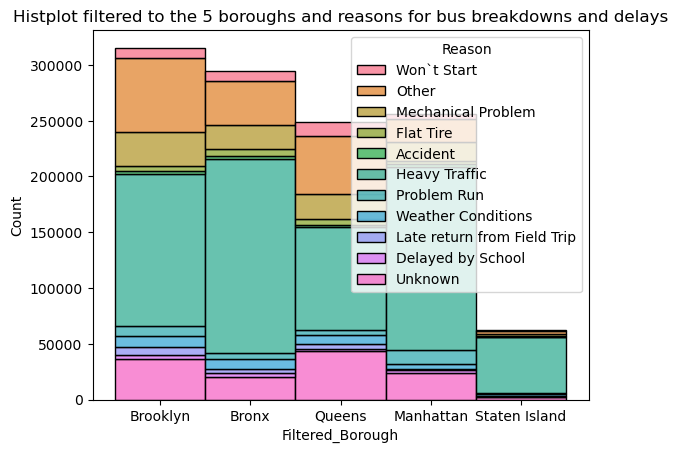

In [11]:
sns.histplot(
    aggregated_reason,
    x = 'Filtered_Borough',
    hue = 'Reason',
    multiple = 'stack'
)
plt.title("Histplot filtered to the 5 boroughs and reasons for bus breakdowns and delays")
plt.show()

In [12]:
aggregated_reason['Reason'].value_counts()

Reason
Heavy Traffic                  680510
Other                          192512
Unknown                        144304
Mechanical Problem              99664
Problem Run                     42328
Won`t Start                     37999
Weather Conditions              35599
Flat Tire                       22617
Late return from Field Trip     17367
Delayed by School               11312
Accident                         9917
Name: count, dtype: int64

In [13]:
aggregated_reason[['Filtered_Borough', 'Reason']].value_counts()

Filtered_Borough  Reason                     
Bronx             Heavy Traffic                  173318
Manhattan         Heavy Traffic                  163815
Brooklyn          Heavy Traffic                  136606
Queens            Heavy Traffic                   92753
Brooklyn          Other                           66237
Queens            Other                           51280
Staten Island     Heavy Traffic                   50244
Queens            Unknown                         43627
Bronx             Other                           39542
Brooklyn          Unknown                         36618
                  Mechanical Problem              30608
Manhattan         Unknown                         24273
Queens            Mechanical Problem              22694
Manhattan         Other                           21323
Bronx             Mechanical Problem              21017
                  Unknown                         20665
Manhattan         Mechanical Problem              16653
  

In [14]:
counts_table = aggregated_reason[['Filtered_Borough', 'Reason']].value_counts().reset_index(name='counts')
counts_table

,Filtered_Borough,Reason,counts
0,Bronx,Heavy Traffic,173318
1,Manhattan,Heavy Traffic,163815
2,Brooklyn,Heavy Traffic,136606
3,Queens,Heavy Traffic,92753
4,Brooklyn,Other,66237
5,Queens,Other,51280
6,Staten Island,Heavy Traffic,50244
7,Queens,Unknown,43627
8,Bronx,Other,39542
9,Brooklyn,Unknown,36618


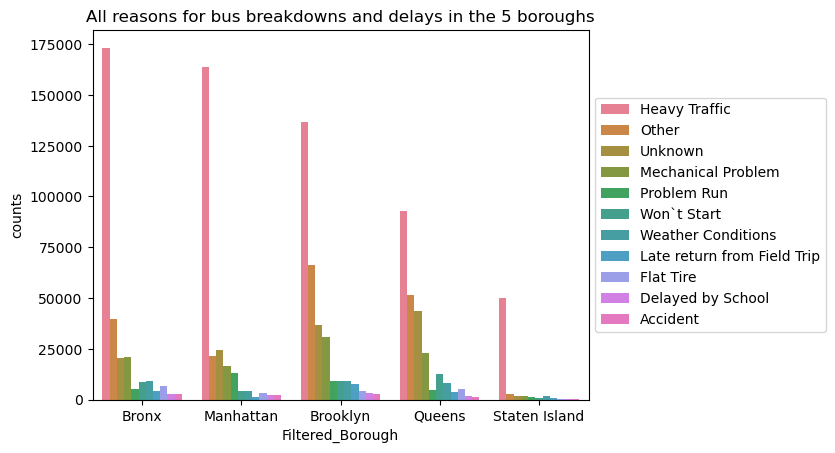

In [15]:
sns.barplot(
    data = counts_table,
    x = 'Filtered_Borough',
    y = 'counts',
    hue = 'Reason'
)
plt.title("All reasons for bus breakdowns and delays in the 5 boroughs")
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.show()

In [16]:
aggregated_reason['Traffic_Type'] = aggregated_reason['Reason'].apply(
    lambda x: 'Heavy Traffic' if x == 'Heavy Traffic' else 'Non-Heavy Traffic'
)
aggregated_reason.sample(20)

,Boro,Reason,Filtered_Borough,Traffic_Type
1047744,Bronx,Heavy Traffic,Bronx,Heavy Traffic
525764,Manhattan,Heavy Traffic,Manhattan,Heavy Traffic
1017596,Queens,Other,Queens,Non-Heavy Traffic
833034,Manhattan,Heavy Traffic,Manhattan,Heavy Traffic
482516,Nassau County,Other,NaN,Non-Heavy Traffic
121714,Queens,Unknown,Queens,Non-Heavy Traffic
1063903,Bronx,Heavy Traffic,Bronx,Heavy Traffic
996317,Brooklyn,Other,Brooklyn,Non-Heavy Traffic
23100,Manhattan,Weather Conditions,Manhattan,Non-Heavy Traffic
399184,Brooklyn,Mechanical Problem,Brooklyn,Non-Heavy Traffic


In [17]:
Traffic_table = aggregated_reason[['Filtered_Borough', 'Traffic_Type']].value_counts().reset_index(name='counts')
Traffic_table

,Filtered_Borough,Traffic_Type,counts
0,Brooklyn,Non-Heavy Traffic,178948
1,Bronx,Heavy Traffic,173318
2,Manhattan,Heavy Traffic,163815
3,Queens,Non-Heavy Traffic,155643
4,Brooklyn,Heavy Traffic,136606
5,Bronx,Non-Heavy Traffic,120970
6,Queens,Heavy Traffic,92753
7,Manhattan,Non-Heavy Traffic,92555
8,Staten Island,Heavy Traffic,50244
9,Staten Island,Non-Heavy Traffic,11783


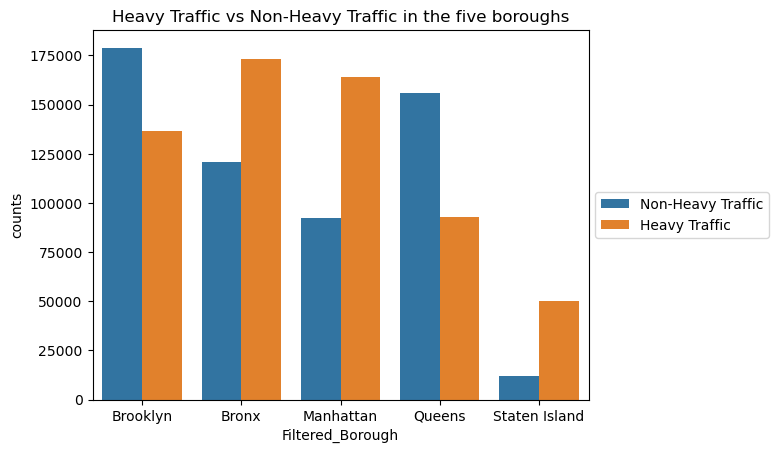

In [18]:
sns.barplot(
    data = Traffic_table,
    x = 'Filtered_Borough',
    y = 'counts',
    hue = 'Traffic_Type'
)
plt.title("Heavy Traffic vs Non-Heavy Traffic in the five boroughs")
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.show()


In [19]:
table = counts_table.pivot_table(
    index = "Filtered_Borough",
    columns = "Reason",
    values = "counts"
)
table

Reason,Accident,Delayed by School,Flat Tire,Heavy Traffic,Late return from Field Trip,Mechanical Problem,Other,Problem Run,Unknown,Weather Conditions,Won`t Start
Filtered_Borough,,,,,,,,,,,
Bronx,2726.0,2816.0,6885.0,173318.0,4012.0,21017.0,39542.0,5391.0,20665.0,9255.0,8661.0
Brooklyn,2709.0,3324.0,4361.0,136606.0,7453.0,30608.0,66237.0,9269.0,36618.0,9228.0,9141.0
Manhattan,2088.0,2250.0,3210.0,163815.0,1025.0,16653.0,21323.0,13155.0,24273.0,4153.0,4425.0
Queens,1440.0,1942.0,5409.0,92753.0,3933.0,22694.0,51280.0,4792.0,43627.0,8087.0,12439.0
Staten Island,197.0,479.0,465.0,50244.0,725.0,1732.0,2785.0,1300.0,1910.0,1632.0,558.0
